# MLP Training Optimization: Backpropagation vs Particle Swarm Optimization

This notebook compares two training strategies for a small Multilayer Perceptron (MLP) applied to the UCI Wine classification dataset:

1. **Backpropagation**, the conventional gradient-based training strategy.
2. **Particle Swarm Optimization (PSO)**, a population-based metaheuristic used to directly optimize the network weights.

The goal is not only to obtain good classification performance, but also to analyze how a neural network can be trained either through gradient information or through direct search in the parameter space.


## 1. Experimental Setup

The experiment uses the Wine dataset available in `scikit-learn`. The dataset contains 178 samples, 13 numerical features, and 3 wine classes.

To make the comparison fair, both methods use the same architecture:

- Input layer: 13 features
- Hidden layer: 4 neurons
- Output layer: 3 neurons
- Hidden activation: sigmoid
- Output activation: sigmoid
- Objective function: Mean Squared Error (MSE)
- Prediction rule: class with the highest output activation


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

seed = 42
np.random.seed(seed)


## 2. Load and Prepare the Dataset

The original notebooks used a local `wine.data` file. For a public repository, using `load_wine()` makes the notebook easier to reproduce because the dataset is loaded directly from `scikit-learn`.


In [15]:
wine = load_wine()

X = wine.data
y = wine.target
class_names = wine.target_names
feature_names = wine.feature_names

df = pd.DataFrame(X, columns=feature_names)
df["class"] = y

print(f"Dataset shape: {df.shape}")
print(f"Number of classes: {len(np.unique(y))}")
df.head()


Dataset shape: (178, 14)
Number of classes: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [16]:
X_train, X_test, y_train_labels, y_test_labels = train_test_split(
    X,
    y,
    test_size = 0.30,
    random_state = seed,
    stratify = y,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train_labels.reshape(-1, 1))
y_test = encoder.transform(y_test_labels.reshape(-1, 1))

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Input features: {X_train.shape[1]}")
print(f"Output classes: {y_train.shape[1]}")


Training samples: 124
Testing samples: 54
Input features: 13
Output classes: 3


## 3. MLP Implementation from Scratch

The same forward propagation function is used by both training strategies. This ensures that the comparison focuses on the optimization method rather than on differences in model architecture.


In [17]:
def sigmoid(X: np.ndarray) -> np.ndarray:
    """Sigmoid activation"""
    return 1 / (1 + np.exp(-X))


def sigmoid_derivative_from_z(X: np.ndarray) -> np.ndarray:
    """Derivative of the sigmoid function using its pre-activation value"""
    s = sigmoid(X)
    return s * (1 - s)


def forward(X_input: np.ndarray, W1: np.ndarray, W2: np.ndarray):
    """Forward pass for a one-hidden-layer MLP"""
    z_hidden = X_input @ W1
    a_hidden = sigmoid(z_hidden)

    z_output = a_hidden @ W2
    a_output = sigmoid(z_output)

    return z_hidden, a_hidden, z_output, a_output


def mse_loss(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean Squared Error objective"""
    return np.mean((y_true - y_pred) ** 2)


def predict_labels(X_input: np.ndarray, W1: np.ndarray, W2: np.ndarray) -> np.ndarray:
    """Predict class labels using the largest output activation"""
    _, _, _, y_pred = forward(X_input, W1, W2)
    return np.argmax(y_pred, axis=1)


def initialize_weights(n_input: int, n_hidden: int, n_output: int, seed: int = seed, scale: float = 0.1):
    """Initialize network weights with a small normal distribution"""
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, scale, size=(n_input, n_hidden))
    W2 = rng.normal(0, scale, size=(n_hidden, n_output))
    return W1, W2


## Neural Network Architecture

The classification model used in this project is a simple Multilayer Perceptron (MLP) designed for the Wine multiclass classification problem.

The network follows a fully connected feedforward architecture composed of an input layer, one hidden layer, and an output layer:

- **Input layer:** 13 neurons, corresponding to the 13 numerical features of the Wine dataset.
- **Hidden layer:** 4 neurons, used to learn an intermediate nonlinear representation of the input data.
- **Output layer:** 3 neurons, corresponding to the three wine classes in the dataset.

The model uses the sigmoid activation function in both the hidden and output layers. Each input sample is propagated through the network using two weight matrices:

$$
W_1 \in \mathbb{R}^{13 \times 4}
$$

$$
W_2 \in \mathbb{R}^{4 \times 3}
$$

where $W_1$ maps the input features to the hidden layer, and $W_2$ maps the hidden representation to the output layer.

In this project, the same MLP architecture is trained using two different optimization strategies:

1. **Backpropagation**, which updates the network weights using gradient-based learning.
2. **Particle Swarm Optimization (PSO)**, which treats all network weights as a single candidate solution vector and optimizes them using a population-based search process.

This allows a direct comparison between conventional neural network training and metaheuristic-based weight optimization under the same model architecture.

For simplicity, this implementation does not include bias terms.

In [18]:
N_INPUT = X_train.shape[1]
N_HIDDEN = 4
N_OUTPUT = y_train.shape[1]

## 4. Training Strategy 1: Backpropagation

Backpropagation updates the network weights using gradient information. In this implementation, stochastic updates are performed sample by sample.


In [19]:
def train_backpropagation(
    X_train: np.ndarray,
    y_train: np.ndarray,
    n_hidden: int,
    learning_rate: float,
    max_epochs: int,
    tolerance: float,
    seed: int,
):
    n_input = X_train.shape[1]
    n_output = y_train.shape[1]

    W1, W2 = initialize_weights(n_input, n_hidden, n_output, seed=seed)
    history = []

    for epoch in range(max_epochs):

        for i in range(len(X_train)):
            x_i = X_train[i]
            y_i = y_train[i]

            z_hidden, a_hidden, z_output, a_output = forward(x_i, W1, W2)

            error_output = a_output - y_i
            delta_output = error_output * sigmoid_derivative_from_z(z_output)

            error_hidden = W2 @ delta_output
            delta_hidden = error_hidden * sigmoid_derivative_from_z(z_hidden)

            grad_W2 = np.outer(a_hidden, delta_output)
            grad_W1 = np.outer(x_i, delta_hidden)

            W1 -= learning_rate * grad_W1
            W2 -= learning_rate * grad_W2

        _, _, _, train_pred = forward(X_train, W1, W2)
        train_mse = mse_loss(y_train, train_pred)
        history.append(train_mse)

        if train_mse <= tolerance:
            break

    return W1, W2, history


In [20]:
W1_bp, W2_bp, history_bp = train_backpropagation(
    X_train,
    y_train,
    n_hidden = N_HIDDEN,
    learning_rate = 0.01,
    max_epochs = 5000,
    tolerance = 0.01,
    seed=seed,
)

print(f"Backpropagation completed in {len(history_bp)} epochs")
print(f"Final training MSE: {history_bp[-1]:.6f}")


/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_51355/1624501096.py:14: RuntimeWarning: divide by zero encountered in matmul
  z_hidden = X_input @ W1
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_51355/1624501096.py:14: RuntimeWarning: overflow encountered in matmul
  z_hidden = X_input @ W1
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_51355/1624501096.py:14: RuntimeWarning: invalid value encountered in matmul
  z_hidden = X_input @ W1


Backpropagation completed in 348 epochs
Final training MSE: 0.009972


## 5. Training Strategy 2: Particle Swarm Optimization

PSO treats each candidate solution as a complete vector of MLP weights. Instead of computing gradients, the algorithm searches the weight space using a population of particles.

Each particle contains all weights from:

- Input layer to hidden layer
- Hidden layer to output layer


In [21]:
# PSO constants
W = 1.0      # Inertia weight
C1 = 0.8     # Cognitive coefficient
C2 = 0.2     # Social coefficient
mu = 100     # Swarm size

mse_tol = 0.01
max_evaluations = 100000
init_scale = 0.1

def flatten_weights(W1: np.ndarray, W2: np.ndarray) -> np.ndarray:
    """
    Convert the two MLP weight matrices into a single one-dimensional vector.
    Each PSO particle represents one complete set of network weights.
    """
    return np.concatenate([W1.flatten(), W2.flatten()])

def unpack_particle(
    particle: np.ndarray,
    n_input: int,
    n_hidden: int,
    n_output: int,
):
    """
    Convert a PSO particle back into the MLP weight matrices.
    """
    n_weights_input_hidden = n_input * n_hidden

    W1 = particle[:n_weights_input_hidden].reshape(n_input, n_hidden)
    W2 = particle[n_weights_input_hidden:].reshape(n_hidden, n_output)

    return W1, W2

def initialize_particles(
    n_particles: int,
    n_input: int,
    n_hidden: int,
    n_output: int,
    init_scale: float,
    seed: int,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    population = []

    for _ in range(n_particles):
        W1 = rng.normal(0, init_scale, size=(n_input, n_hidden)).flatten()
        W2 = rng.normal(0, init_scale, size=(n_hidden, n_output)).flatten()

        particle = np.concatenate([W1, W2])
        population.append(particle)

    return np.array(population)

def fitness(
    particle: np.ndarray,
    X_train: np.ndarray,
    y_train: np.ndarray,
    n_hidden: int,
) -> float:
    """
    Objective function for PSO.
    A particle is evaluated by unpacking its weights, performing forward propagation,
    and computing the MSE over the training set
    """
    n_input = X_train.shape[1]
    n_output = y_train.shape[1]

    W1, W2 = unpack_particle(
        particle,
        n_input,
        n_hidden,
        n_output
    )

    _, _, _, y_pred = forward(X_train, W1, W2)

    return mse_loss(y_train, y_pred)

def velocity_tp1(
    velocity: np.ndarray,
    personal_best: np.ndarray,
    global_best: np.ndarray,
    position: np.ndarray,
    inertia: float,
    cognitive: float,
    social: float,
    rng,
) -> np.ndarray:
    """
    Compute the velocity update for the next PSO iteration
    """
    r1 = rng.uniform(0, 1, size=position.shape)
    r2 = rng.uniform(0, 1, size=position.shape)

    inertia_term = inertia * velocity
    cognitive_term = cognitive * r1 * (personal_best - position)
    social_term = social * r2 * (global_best - position)

    return inertia_term + cognitive_term + social_term

def x_new(position: np.ndarray, velocity: np.ndarray) -> np.ndarray:
    """
    Update particle positions using the current velocity.
    """
    return position + velocity

def PSO(
    initial_population: np.ndarray,
    X_train: np.ndarray,
    y_train: np.ndarray,
    n_hidden: int,
    inertia: float,
    cognitive: float,
    social: float,
    tolerance: float,
    max_evaluations: int,
    seed: int,
):
    """
    Particle Swarm Optimization for direct MLP weight optimization
    """
    rng = np.random.default_rng(seed)

    x = initial_population.copy()

    fit = np.array([
        fitness(ind, X_train, y_train, n_hidden)
        for ind in x
    ])

    velocity = np.zeros_like(x)

    personal_best = x.copy()
    personal_best_fitness = fit.copy()

    evals = len(x)
    history = [np.min(personal_best_fitness)]

    while evals + len(x) <= max_evaluations:
        best_idx = np.argmin(personal_best_fitness)

        global_best = personal_best[best_idx].copy()
        global_best_fitness = personal_best_fitness[best_idx]

        velocity = velocity_tp1(
            velocity,
            personal_best,
            global_best,
            x,
            inertia,
            cognitive,
            social,
            rng
        )

        x_candidate = x_new(x, velocity)

        new_fit = np.array([
            fitness(ind, X_train, y_train, n_hidden)
            for ind in x_candidate
        ])

        for i in range(len(x)):
            if new_fit[i] < personal_best_fitness[i]:
                personal_best[i] = x_candidate[i]
                personal_best_fitness[i] = new_fit[i]

        x = x_candidate
        fit = new_fit
        evals += len(x)

        best_current_fitness = np.min(personal_best_fitness)
        history.append(best_current_fitness)

        if best_current_fitness <= tolerance:
            break

    best_idx = np.argmin(personal_best_fitness)
    best_particle = personal_best[best_idx]

    n_input = X_train.shape[1]
    n_output = y_train.shape[1]

    W1, W2 = unpack_particle(
        best_particle,
        n_input,
        n_hidden,
        n_output
    )

    return W1, W2, history

In [22]:
n_input = X_train.shape[1]
n_output = y_train.shape[1]

initial_population = initialize_particles(
    n_particles=mu,
    n_input=n_input,
    n_hidden=N_HIDDEN,
    n_output=n_output,
    init_scale=init_scale,
    seed=seed,
)

W1_pso, W2_pso, history_pso = PSO(
    initial_population,
    X_train,
    y_train,
    n_hidden = 4,
    inertia = 1.0,
    cognitive = 0.8,
    social = 0.2,
    tolerance = 0.01,
    max_evaluations = 100000,
    seed = 42,
)

print(f"PSO completed in {len(history_pso) - 1} iterations")
print(f"Final training MSE: {history_pso[-1]:.6f}")

PSO completed in 98 iterations
Final training MSE: 0.009940


/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_51355/1624501096.py:14: RuntimeWarning: divide by zero encountered in matmul
  z_hidden = X_input @ W1
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_51355/1624501096.py:14: RuntimeWarning: overflow encountered in matmul
  z_hidden = X_input @ W1
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_51355/1624501096.py:14: RuntimeWarning: invalid value encountered in matmul
  z_hidden = X_input @ W1


## 6. Evaluation Metrics

Both methods are evaluated on the held-out test set using:

- Accuracy
- Macro precision
- Macro recall
- Macro F1-score
- Training MSE
- Testing MSE


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(
    method_name: str,
    W1: np.ndarray,
    W2: np.ndarray,
    history: list,
    subtract_initial_history: bool = False,
):
    _, _, _, train_output = forward(X_train, W1, W2)
    _, _, _, test_output = forward(X_test, W1, W2)

    test_pred = np.argmax(test_output, axis=1)

    epochs_or_iterations = len(history) - 1 if subtract_initial_history else len(history)

    return {
        "Method": method_name,
        "Training MSE": mse_loss(y_train, train_output),
        "Testing MSE": mse_loss(y_test, test_output),
        "Test Accuracy": accuracy_score(y_test_labels, test_pred),
        "Macro Precision": precision_score(y_test_labels, test_pred, average="macro"),
        "Macro Recall": recall_score(y_test_labels, test_pred, average="macro"),
        "Macro F1-score": f1_score(y_test_labels, test_pred, average="macro"),
        "Epochs / Iterations": epochs_or_iterations,
    }

In [24]:
results = pd.DataFrame([
    evaluate_model(
        method_name="MLP + Backpropagation",
        W1=W1_bp,
        W2=W2_bp,
        history=history_bp,
        subtract_initial_history=False
    ),
    evaluate_model(
        method_name="MLP + PSO",
        W1=W1_pso,
        W2=W2_pso,
        history=history_pso,
        subtract_initial_history=True
    )
])

results

/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_51355/1624501096.py:14: RuntimeWarning: divide by zero encountered in matmul
  z_hidden = X_input @ W1
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_51355/1624501096.py:14: RuntimeWarning: overflow encountered in matmul
  z_hidden = X_input @ W1
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_51355/1624501096.py:14: RuntimeWarning: invalid value encountered in matmul
  z_hidden = X_input @ W1
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_51355/1624501096.py:14: RuntimeWarning: divide by zero encountered in matmul
  z_hidden = X_input @ W1
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_51355/1624501096.py:14: RuntimeWarning: overflow encountered in matmul
  z_hidden = X_input @ W1
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_51355/1624501096.py:14: RuntimeWarning: invalid value encountered in matmul
  z_hidden = X_input @ W1


,Method,Training MSE,Testing MSE,Test Accuracy,Macro Precision,Macro Recall,Macro F1-score,Epochs / Iterations
0,MLP + Backpropagation,0.009972,0.021747,0.981481,0.982456,0.984127,0.982861,348
1,MLP + PSO,0.009940,0.056716,0.907407,0.935897,0.896296,0.907894,98


### Results Analysis

The obtained results show that both training strategies were able to optimize the MLP successfully, although they presented different behavior in terms of generalization performance.

The PSO-trained MLP achieved the lowest training MSE, with a value of **0.009940**, slightly outperforming the Backpropagation-trained MLP, which obtained a training MSE of **0.009972**. This indicates that PSO was able to find a competitive set of network weights directly in the parameter space, even without using gradient-based updates.

However, the Backpropagation-trained MLP achieved better performance on the test set. It obtained a testing MSE of **0.021747**, a test accuracy of **0.981481**, and a macro F1-score of **0.982861**. In comparison, the PSO-trained MLP obtained a higher testing MSE of **0.056716**, a test accuracy of **0.907407**, and a macro F1-score of **0.907894**.

These results suggest that, although PSO was effective at minimizing the training error, Backpropagation produced a model with stronger generalization performance on unseen data. This behavior is expected in many supervised learning scenarios, since gradient-based optimization is specifically designed to efficiently adjust neural network parameters with respect to the loss landscape.

From an optimization perspective, the results are still relevant because PSO reached a training MSE comparable to Backpropagation in only **98 iterations**, while Backpropagation required **348 epochs**. Nevertheless, the lower test performance of PSO indicates that direct weight optimization through a population-based method may require additional tuning, multiple independent runs, or regularization strategies to improve generalization.

Overall, this experiment shows that PSO can be used as an alternative optimization strategy for training small neural networks, but Backpropagation remains more effective in this experiment when considering test accuracy, testing MSE, and macro-averaged classification metrics.

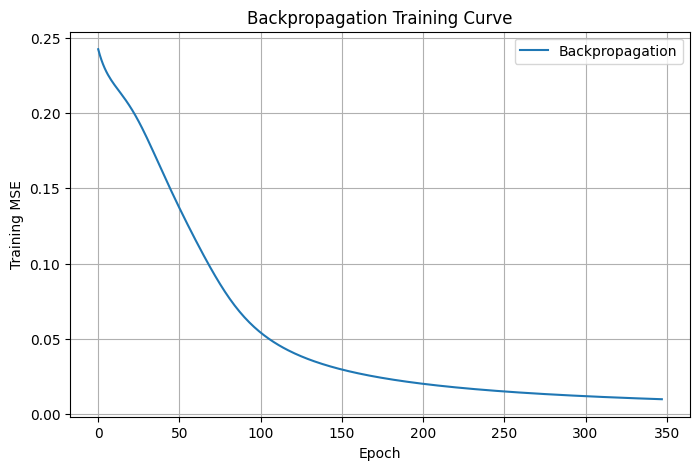

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history_bp, label="Backpropagation")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Backpropagation Training Curve")
plt.legend()
plt.grid(True)
plt.show()


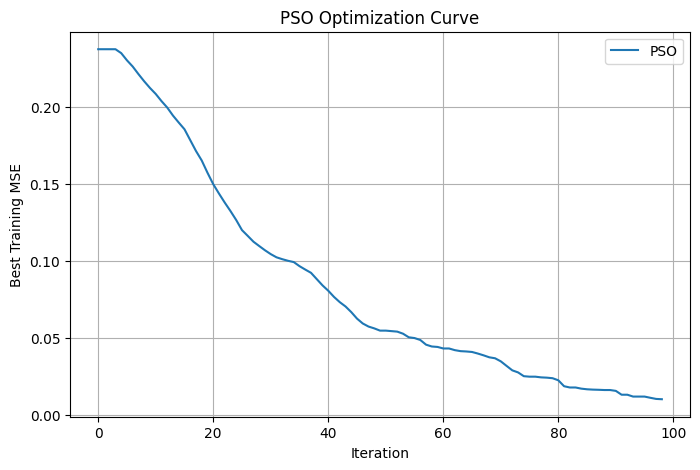

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history_pso, label="PSO")
plt.xlabel("Iteration")
plt.ylabel("Best Training MSE")
plt.title("PSO Optimization Curve")
plt.legend()
plt.grid(True)
plt.show()


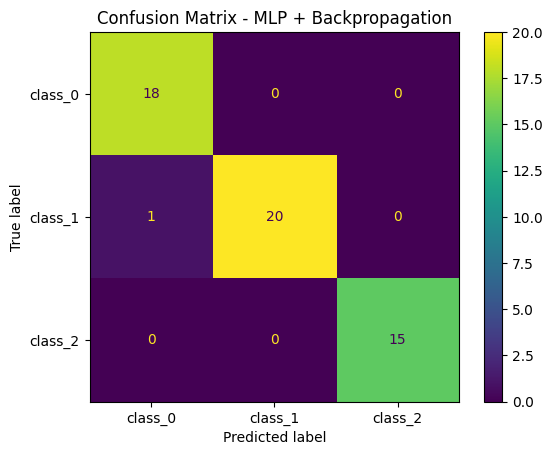

In [27]:
bp_test_pred = predict_labels(X_test, W1_bp, W2_bp)
pso_test_pred = predict_labels(X_test, W1_pso, W2_pso)

cm_bp = confusion_matrix(y_test_labels, bp_test_pred)
cm_pso = confusion_matrix(y_test_labels, pso_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bp, display_labels=class_names)
disp.plot()
plt.title("Confusion Matrix - MLP + Backpropagation")
plt.show()


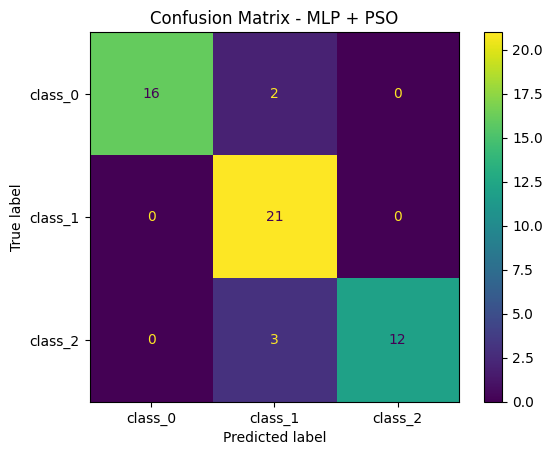

In [28]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pso, display_labels=class_names)
disp.plot()
plt.title("Confusion Matrix - MLP + PSO")
plt.show()


## 7. Discussion

The backpropagation-based MLP uses gradient information to update the weights directly through the chain rule. This makes it computationally efficient for neural network training and typically very effective for small supervised learning problems such as the Wine dataset.

The PSO-based MLP follows a different strategy. Instead of using gradients, each particle represents a full set of network weights, and the swarm searches for a weight configuration that minimizes the MSE. This demonstrates that the neural network can be trained as a direct optimization problem over the parameter space.

From a portfolio perspective, this comparison is valuable because it shows both:

- Understanding of neural network training fundamentals.
- Ability to apply population-based metaheuristics to machine learning optimization problems.


### 8. Conclusions

This project compared two training strategies for a manually implemented MLP classifier: standard Backpropagation and Particle Swarm Optimization. Both methods were able to train the network successfully on the Wine dataset, but they showed different strengths.

PSO obtained the lowest training MSE, which demonstrates its ability to search directly for suitable neural network weights without relying on gradient information. However, Backpropagation achieved better test performance across all classification metrics, including accuracy, macro precision, macro recall, and macro F1-score.

The results indicate that PSO is a viable optimization alternative for small neural networks and can reach competitive training error, but in this experiment Backpropagation provided better generalization. Future improvements could include running PSO with multiple random seeds, tuning its hyperparameters, increasing the swarm size, adding bias terms to the MLP, and comparing the implementation against a standard library baseline such as `sklearn.neural_network.MLPClassifier`.